# Plot one single out eddy with mask

plot anomaly fields for one single out eddy (one ac and one c eddy)

In [9]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
from matplotlib.patches import Ellipse
import cmocean
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

In [10]:
#import data from 1r_dn23 with r > q75 and e < 20
edso1_clt_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20.nc")
edso1_clt_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20.nc")

In [11]:
eerie_cat=intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
da_atmos = eerie_cat["dkrz"]["disk"]["model-output"]["icon-esm-er"]["hist-1950"]["v20240618"]["atmos"]["gr025"]["2d_daily_mean"].to_dask()
da_ocean = eerie_cat["dkrz"]["disk"]["model-output"]["icon-esm-er"]["hist-1950"]["v20240618"]["ocean"]["gr025"]["2d_daily_mean"].to_dask()

In [12]:
#select atmos and ocean data for SO
da_atmos_so = da_atmos.where(da_atmos.lat < -50, drop = True)
da_ocean_so = da_ocean.where(da_ocean.lat < -50, drop = True)

In [13]:
da_atmos_so_sfcwind = da_atmos_so.sfcwind.squeeze(dim="height_2")

#### Anticyclonic eddy selection (an eddy with strong positive dif_sst)

In [14]:
# Find max value
max_sst = edso1_clt_ac_q75_e20.dif_sst.max()

# Select eddy where dif_sst equals the max
eddy_max_sst = edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst == max_sst, drop=True)


In [15]:
eddy_max_sst

<xarray.Dataset>
Dimensions:                        (obs: 1, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 1.237e+06
    quantile                       float64 0.75
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 0.2502
    cost_association               (obs) float32 0.1146
    effective_area                 (obs) float32 1.284e+10
    effective_contour_height       (obs) float32 0.108
    effective_contour_latitude     (obs, NbSample) float64 -60.8 -60.9 ... -60.8
    effective_contour_longitude    (obs, NbSample) float64 293.0 293.2 ... 293.0
    ...                             ...
    dif_clt                        (obs) float64 0.0002789
    sst_mean_ed                    (obs) float64 4.53
    sst_npoints_ed                 (obs) float64 32.0
    sst_mean_donut                 (obs) float64 3.092
    sst_npoints_donut              (obs) float64 176.0
    dif_sst                        (obs) float64 1.438
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [16]:
eddy_min_sst = edso1_clt_c_q75_e20.sel(obs=[1924803])


In [17]:
#change radius to degree
radius_lat = eddy_max_sst["effective_radius"].values / 111320
radius_lon = eddy_max_sst["effective_radius"].values /(111320 * np.cos(np.deg2rad(eddy_max_sst["latitude"].values)))
        
#add new radius_lat/lon to eddy_max_sst
eddy_max_sst = eddy_max_sst.assign(
        radius_lat=("obs", radius_lat),
        radius_lon=("obs", radius_lon))


In [18]:
#change radius to degree
radius_lat = eddy_min_sst["effective_radius"].values / 111320
radius_lon = eddy_min_sst["effective_radius"].values /(111320 * np.cos(np.deg2rad(eddy_min_sst["latitude"].values)))
        
#add new radius_lat/lon to eddy_max_sst
eddy_min_sst = eddy_min_sst.assign(
        radius_lat=("obs", radius_lat),
        radius_lon=("obs", radius_lon))


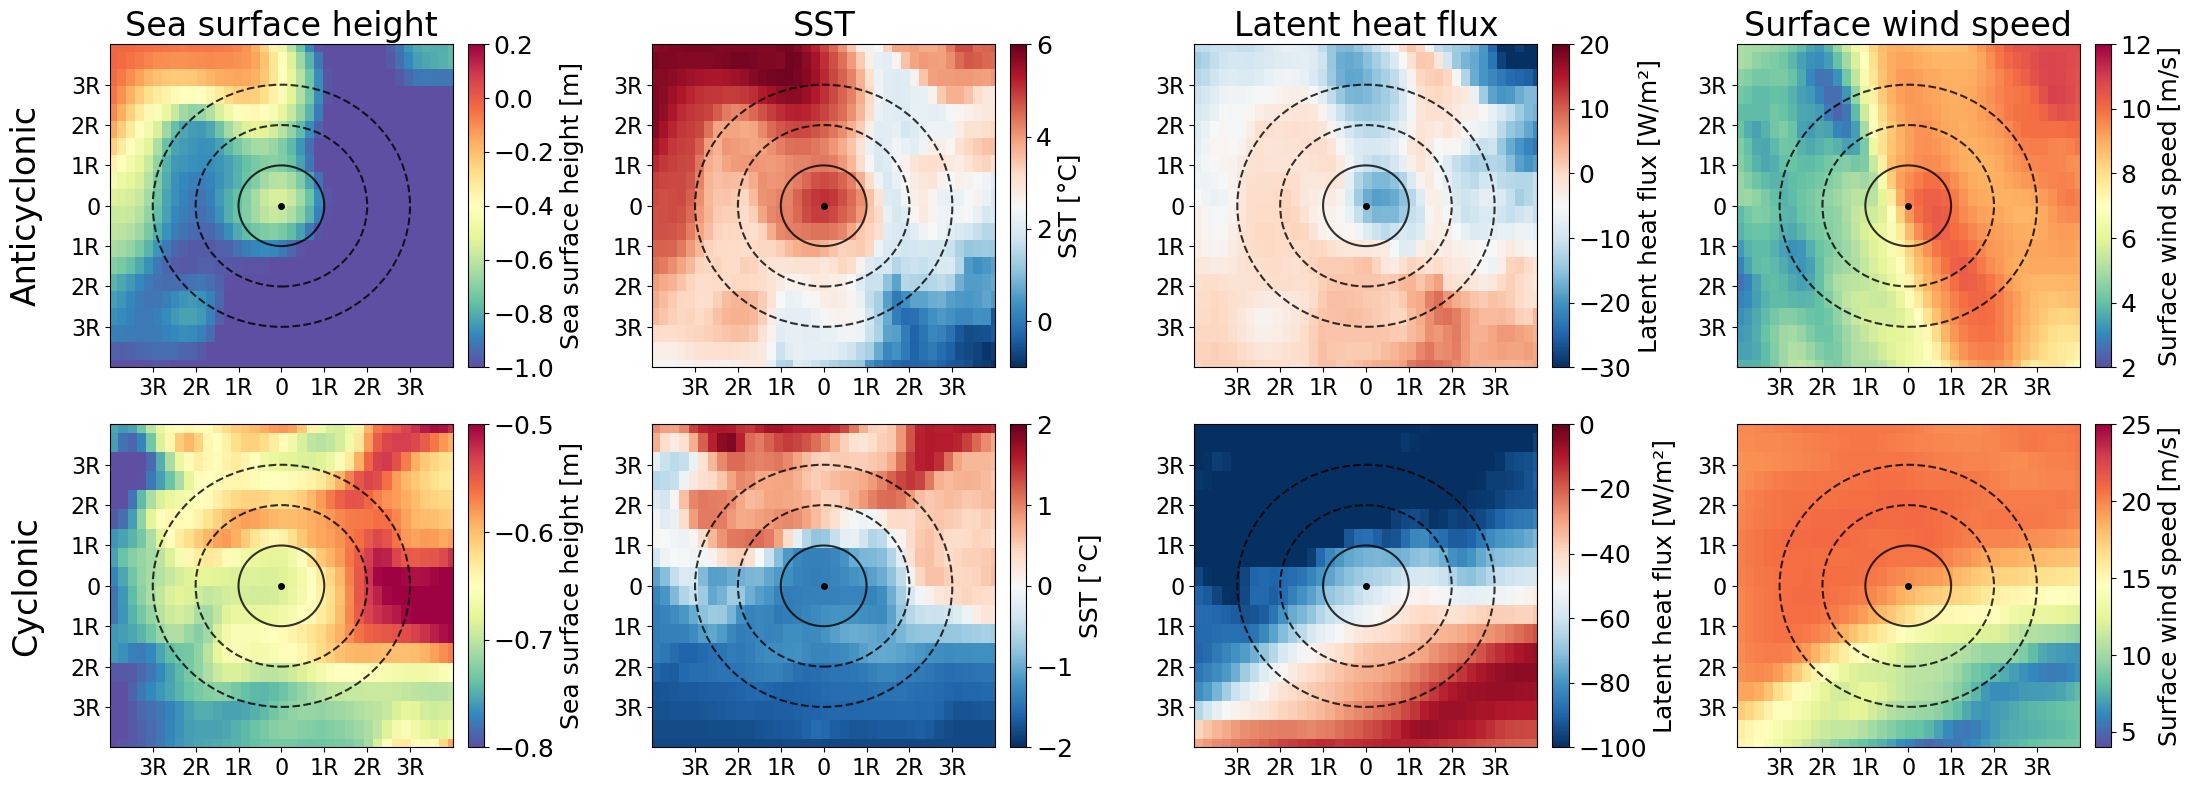

In [19]:
# shared settings
fields = {
    "Sea surface height [m]": "ssh",
    "SST [°C]": "to",
    "Latent heat flux [W/m²]": "hfls",
    "Surface wind speed [m/s]": "sfcwind"
}

# Anticyclonic settings
ac_data = {
    "eddy": eddy_max_sst,
    "colorscales": {
        "Sea surface height [m]": (-1, 0.2),
        "SST [°C]": (-1, 6),
        "Latent heat flux [W/m²]": (-30, 20),
        "Surface wind speed [m/s]": (2, 12)
    },
    "colormaps": {
        "Sea surface height [m]": "Spectral_r",
        "SST [°C]": "RdBu_r",
        "Latent heat flux [W/m²]": "RdBu_r",
        "Surface wind speed [m/s]": "Spectral_r"
    },
    "label": "Anticyclonic"
}

# Cyclonic settings
cy_data = {
    "eddy": eddy_min_sst,
    "colorscales": {
        "Sea surface height [m]": (-0.8, -0.5),
        "SST [°C]": (-2, 2),
        "Latent heat flux [W/m²]": (-100, 0),
        "Surface wind speed [m/s]": (4, 25)
    },
    "colormaps": {
        "Sea surface height [m]": "Spectral_r",
        "SST [°C]": "RdBu_r",
        "Latent heat flux [W/m²]": "RdBu_r",
        "Surface wind speed [m/s]": "Spectral_r"
    },
    "label": "Cyclonic"
}


# 2×4 figure settings

plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

fig, axes = plt.subplots(2, len(fields), figsize=(22, 8), sharex=False, sharey=False)


# helper function to plot one row

def plot_row(ax_row, config):

    eddy = config["eddy"]
    lat0 = float(eddy["latitude"])
    lon0 = float(eddy["longitude"])
    r_lat = float(eddy["radius_lat"])
    r_lon = float(eddy["radius_lon"])

    for ax, (title, varname) in zip(ax_row, fields.items()):

        # Select data
        da_field = (
            da_ocean_so[varname] if varname in da_ocean_so 
            else da_atmos_so[varname] if varname in da_atmos_so
            else da_atmos_so_sfcwind
        )

        field_data = da_field.sel(time=eddy["time"], method="nearest").squeeze()
        lon_vals = field_data["lon"].values
        lat_vals = field_data["lat"].values
        field_vals = field_data.values

        # Color settings
        vmin, vmax = config["colorscales"][title]
        cmap = config["colormaps"][title]

        pcm = ax.pcolormesh(
            lon_vals, lat_vals, field_vals,
            cmap=cmap, shading="auto",
            vmin=vmin, vmax=vmax
        )

        cbar = plt.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(title, fontsize=18)
        cbar.ax.tick_params(labelsize=18)

        # Ellipses
        for factor in [1, 2, 3]:
            ls = "-" if factor == 1 else "--"
            ellipse = Ellipse(
                (lon0, lat0),
                width=2*factor*r_lon,
                height=2*factor*r_lat,
                edgecolor="black",
                facecolor="none",
                lw=1.5,
                linestyle=ls,
                alpha=0.8
            )
            ax.add_patch(ellipse)

        ax.plot(lon0, lat0, "ko", markersize=4)

        # Zoom
        ax.set_xlim(lon0 - 4*r_lon, lon0 + 4*r_lon)
        ax.set_ylim(lat0 - 4*r_lat, lat0 + 4*r_lat)

        # Tick labels in R units
        xticks = lon0 + np.array([-3, -2, -1, 0, 1, 2, 3]) * r_lon
        yticks = lat0 + np.array([-3, -2, -1, 0, 1, 2, 3]) * r_lat

        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_xticklabels(["3R", "2R", "1R", "0", "1R", "2R", "3R"])
        ax.set_yticklabels(["3R", "2R", "1R", "0", "1R", "2R", "3R"])


# Plot both rows

plot_row(axes[0], ac_data)
plot_row(axes[1], cy_data)


# row labels on the left

axes[0,0].set_ylabel("Anticyclonic", fontsize=24, labelpad=20)
axes[1,0].set_ylabel("Cyclonic", fontsize=24, labelpad=20)


# label columns on top row

for ax, title in zip(axes[0], fields.keys()):
    clean_title = title.split(" [")[0]   # remove units
    ax.set_title(clean_title, fontsize=24)



fig.tight_layout()
plt.savefig("eddy_snapshot.pdf")
plt.show()


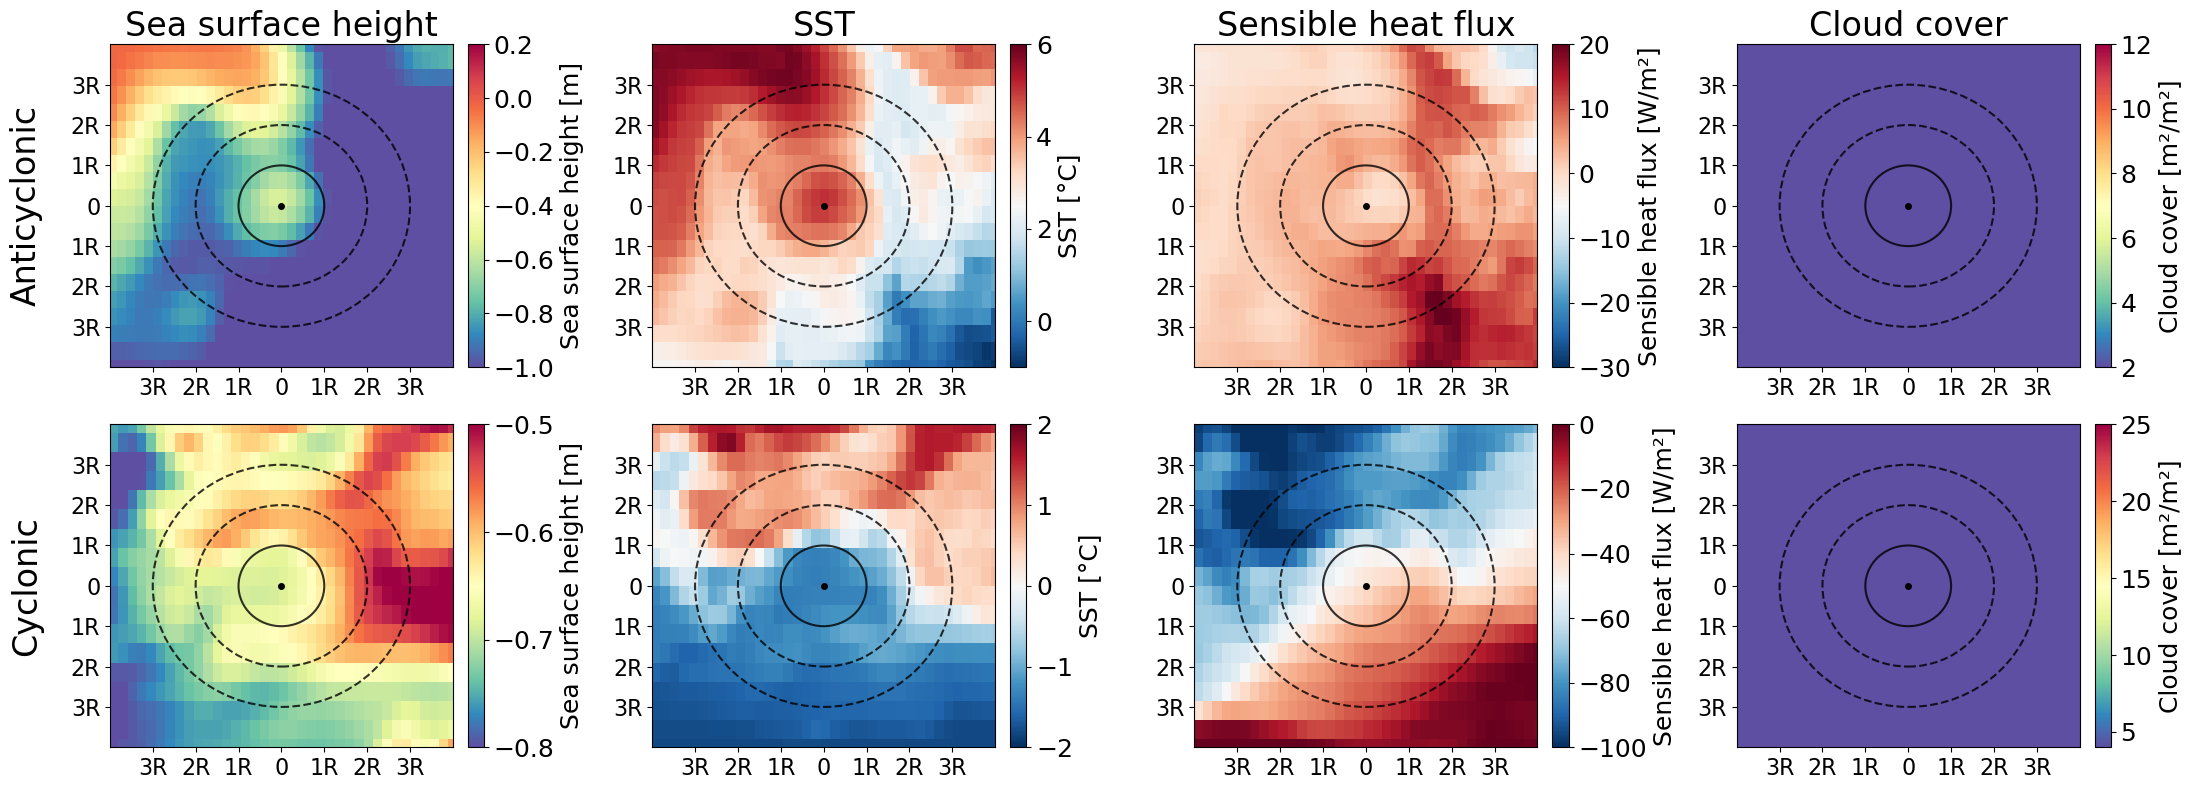

In [21]:
# shared settings
fields = {
    "Sea surface height [m]": "ssh",
    "SST [°C]": "to",
    "Sensible heat flux [W/m²]": "hfss",
    "Cloud cover [m²/m²]": "clt"
}

# Anticyclonic settings
ac_data = {
    "eddy": eddy_max_sst,
    "colorscales": {
        "Sea surface height [m]": (-1, 0.2),
        "SST [°C]": (-1, 6),
        "Sensible heat flux [W/m²]": (-30, 20),
        "Cloud cover [m²/m²]": (2, 12)
    },
    "colormaps": {
        "Sea surface height [m]": "Spectral_r",
        "SST [°C]": "RdBu_r",
        "Sensible heat flux [W/m²]": "RdBu_r",
        "Cloud cover [m²/m²]": "Spectral_r"
    },
    "label": "Anticyclonic"
}

# Cyclonic settings
cy_data = {
    "eddy": eddy_min_sst,
    "colorscales": {
        "Sea surface height [m]": (-0.8, -0.5),
        "SST [°C]": (-2, 2),
        "Sensible heat flux [W/m²]": (-100, 0),
        "Cloud cover [m²/m²]": (4, 25)
    },
    "colormaps": {
        "Sea surface height [m]": "Spectral_r",
        "SST [°C]": "RdBu_r",
        "Sensible heat flux [W/m²]": "RdBu_r",
        "Cloud cover [m²/m²]": "Spectral_r"
    },
    "label": "Cyclonic"
}


# 2×4 figure settings

plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

fig, axes = plt.subplots(2, len(fields), figsize=(22, 8), sharex=False, sharey=False)


# helper function to plot one row

def plot_row(ax_row, config):

    eddy = config["eddy"]
    lat0 = float(eddy["latitude"])
    lon0 = float(eddy["longitude"])
    r_lat = float(eddy["radius_lat"])
    r_lon = float(eddy["radius_lon"])

    for ax, (title, varname) in zip(ax_row, fields.items()):

        # Select data
        da_field = (
            da_ocean_so[varname] if varname in da_ocean_so 
            else da_atmos_so[varname] if varname in da_atmos_so
            else da_atmos_so_sfcwind
        )

        field_data = da_field.sel(time=eddy["time"], method="nearest").squeeze()
        lon_vals = field_data["lon"].values
        lat_vals = field_data["lat"].values
        field_vals = field_data.values

        # Color settings
        vmin, vmax = config["colorscales"][title]
        cmap = config["colormaps"][title]

        pcm = ax.pcolormesh(
            lon_vals, lat_vals, field_vals,
            cmap=cmap, shading="auto",
            vmin=vmin, vmax=vmax
        )

        cbar = plt.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(title, fontsize=18)
        cbar.ax.tick_params(labelsize=18)

        # Ellipses
        for factor in [1, 2, 3]:
            ls = "-" if factor == 1 else "--"
            ellipse = Ellipse(
                (lon0, lat0),
                width=2*factor*r_lon,
                height=2*factor*r_lat,
                edgecolor="black",
                facecolor="none",
                lw=1.5,
                linestyle=ls,
                alpha=0.8
            )
            ax.add_patch(ellipse)

        ax.plot(lon0, lat0, "ko", markersize=4)

        # Zoom
        ax.set_xlim(lon0 - 4*r_lon, lon0 + 4*r_lon)
        ax.set_ylim(lat0 - 4*r_lat, lat0 + 4*r_lat)

        # Tick labels in R units
        xticks = lon0 + np.array([-3, -2, -1, 0, 1, 2, 3]) * r_lon
        yticks = lat0 + np.array([-3, -2, -1, 0, 1, 2, 3]) * r_lat

        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_xticklabels(["3R", "2R", "1R", "0", "1R", "2R", "3R"])
        ax.set_yticklabels(["3R", "2R", "1R", "0", "1R", "2R", "3R"])


# Plot both rows

plot_row(axes[0], ac_data)
plot_row(axes[1], cy_data)


# row labels on the left

axes[0,0].set_ylabel("Anticyclonic", fontsize=24, labelpad=20)
axes[1,0].set_ylabel("Cyclonic", fontsize=24, labelpad=20)


# label columns on top row

for ax, title in zip(axes[0], fields.keys()):
    clean_title = title.split(" [")[0]   # remove units
    ax.set_title(clean_title, fontsize=24)



fig.tight_layout()
plt.savefig("eddy_snapshot_additional.pdf")
plt.show()
